In [8]:
import librosa 
import librosa.display
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns
import IPython.display as idp

from glob import glob
from itertools import cycle


In [9]:
# Setting some Stylistic themes
sns.set_theme(style="white", palette=None)
color_pal = plt.rcParams["axes.prop_cycle"].by_key()["color"]
color_cycle = cycle(plt.rcParams["axes.prop_cycle"].by_key()["color"])

In [10]:
path = "..\\0audio\\Actor_01\\03-01-01-01-01-01-01.wav"

In [11]:
#audio_files = glob('../0audio/*/*.wav') #pretty neat huh

In [12]:
#Play an Example of the Unedited Audio File
idp.Audio(path)

In [13]:
# y, is the raw audio value, and sr is the sample rate
y, sr = librosa.load(path)
print(f'Y value snippet: {y}')
print(f'Size: {len(y)} (number of samples)')
print(f'Sample Rate: {sr} samples per second')

Y value snippet: [ 5.3765390e-08 -2.1233145e-08 -6.0478342e-09 ...  4.8083174e-14
 -9.6233243e-15  2.8714739e-14]
Size: 72838 (number of samples)
Sample Rate: 22050 samples per second


<Axes: title={'center': 'Raw Audio'}>

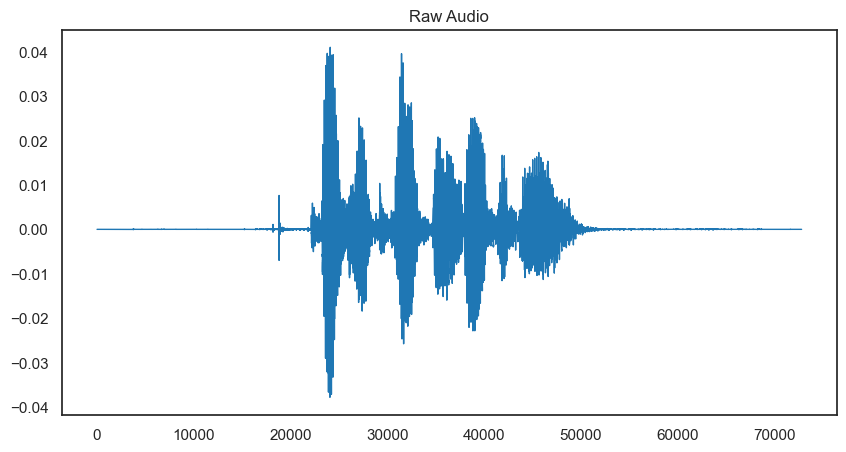

In [14]:
pd.Series(y).plot(figsize=(10,5), 
                  lw=1, 
                  title='Raw Audio')

Above is an example of the raw audio loaded in without any kind of pre-processing. 

We are first going to trim the audio to remove any dead noise. 

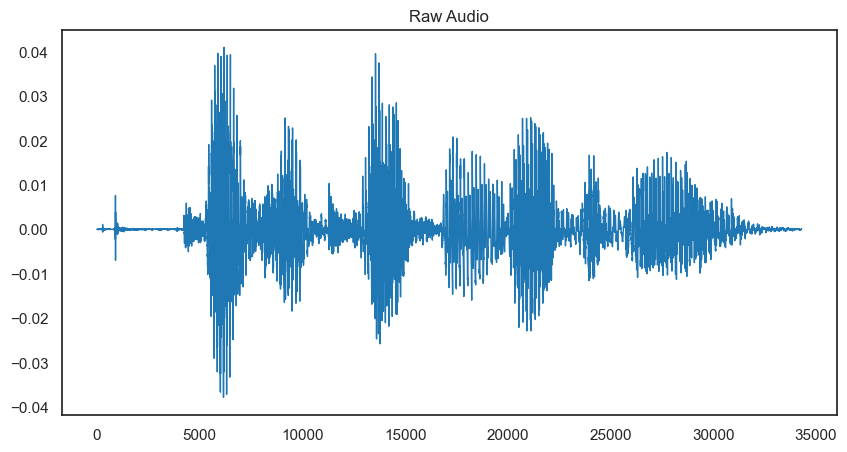

In [15]:
y_trimmed, _ = librosa.effects.trim(y, top_db = 40)
pd.Series(y_trimmed).plot(figsize=(10,5), 
                  lw=1, 
                  title='Raw Audio')
idp.Audio(y_trimmed, rate= sr, normalize=False )

Above we can begin to recognize the characteristic lines of a audio signal.

# Effects of Amplitude changes on audio

We are going to zoom in to get a better look. we are zooming in on a specific set of 100 samples which translate to ~4.54ms of Sound.
I have hadset the y axis to (-.0006,.0004) for easier visualization of the differences once we change the amplitude.

<Axes: title={'center': 'Raw Audio'}>

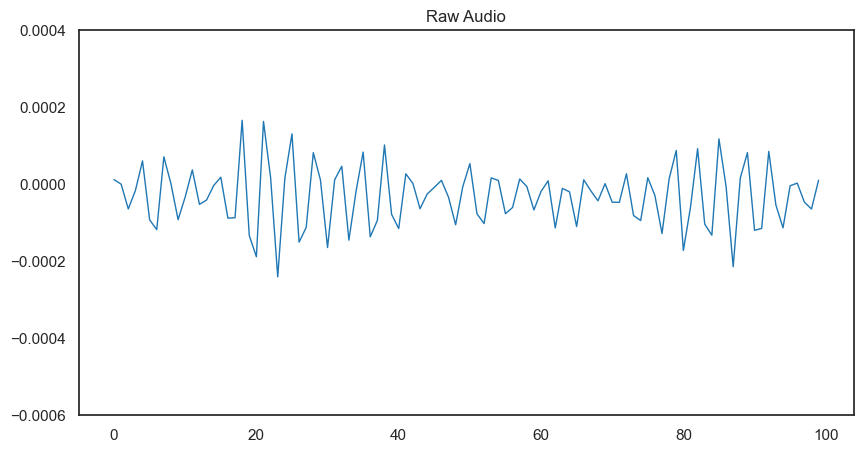

In [17]:
y_sample = pd.Series(y_trimmed[1500:1600])
pd.Series(y_sample).plot(figsize=(10,5), 
                  ylim = (-.0006,.0004),
                  lw=1, 
                  title='Raw Audio')

Here we can now see something a little more familiar. But unlike the clean audio sample we saw in the report, here we have something a little more chaotic. Partyly due the fact that we are working with a real-world sample, and party due the sample rate. If you look closely you can notice the individual sample points and the straight lines between them.

Next we are going to show what increasing and decreasing the frequency does to our sample visually. We will also apply these tranformations to the entire clip to be able to hear it. 

In [18]:
# Choose gains in decibels
gain_up_db   = +6     # louder  (+6 dB ≈ 2×)
gain_down_db = -6      # quieter (‑6 dB ≈ 0.5×)

# Convert dB → linear amplitude factors
gain_up   = librosa.db_to_amplitude(gain_up_db)     # ≈ 1.995
gain_down = librosa.db_to_amplitude(gain_down_db)   # ≈ 0.501



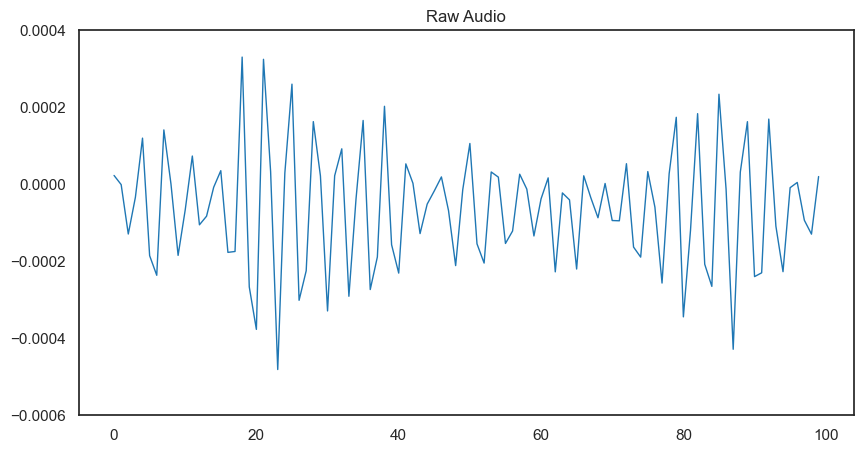

In [19]:
# --- louder version ---
y_trimmed_higher_amp = y_trimmed * gain_up
y_sample_higher_amp  = pd.Series(y_trimmed_higher_amp[1500:1600])

pd.Series(y_sample_higher_amp).plot(figsize=(10,5), 
                  ylim = (-.0006,.0004),
                  lw=1, 
                  title='Raw Audio')
idp.Audio(y_trimmed_higher_amp, rate= sr , normalize=False)

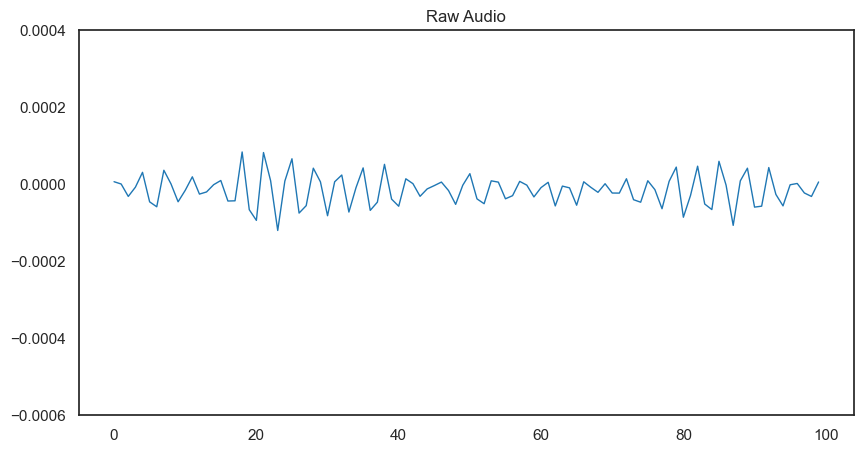

In [20]:
# --- quieter version ---
y_trimmed_lower_amp  = y_trimmed * gain_down
y_sample_lower_amp   = pd.Series(y_trimmed_lower_amp[1500:1600])

pd.Series(y_sample_lower_amp).plot(figsize=(10,5), 
                  ylim = (-.0006,.0004),
                  lw=1, 
                  title='Raw Audio')
idp.Audio(y_trimmed_lower_amp, rate= sr, normalize=False)

# Effects of Frequency changes on audio

Next we are going to showcase the effects that changing the frequency has on an audio sample

In [21]:
n_steps_up   =  +4     # higher pitch  (≈ ×1.26 frequency)
n_steps_down =  -4     # lower pitch   (≈ ×0.79 frequency)

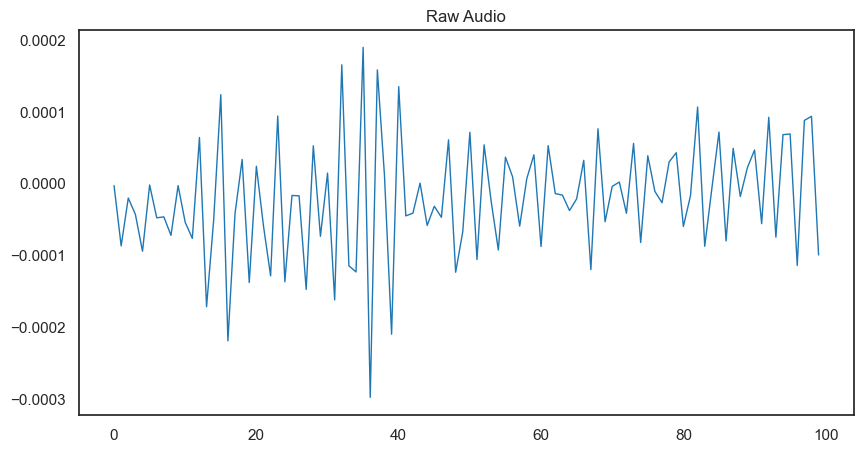

In [22]:
y_trimmed_higher_freq = librosa.effects.pitch_shift(y_trimmed, sr=sr,
                                                   n_steps=n_steps_up)
y_sample_higher_freq = pd.Series(y_trimmed_higher_freq[1500:1600])
pd.Series(y_sample_higher_freq).plot(figsize=(10,5), 
                  lw=1, 
                  title='Raw Audio')
idp.Audio(y_trimmed_higher_freq, rate= sr)

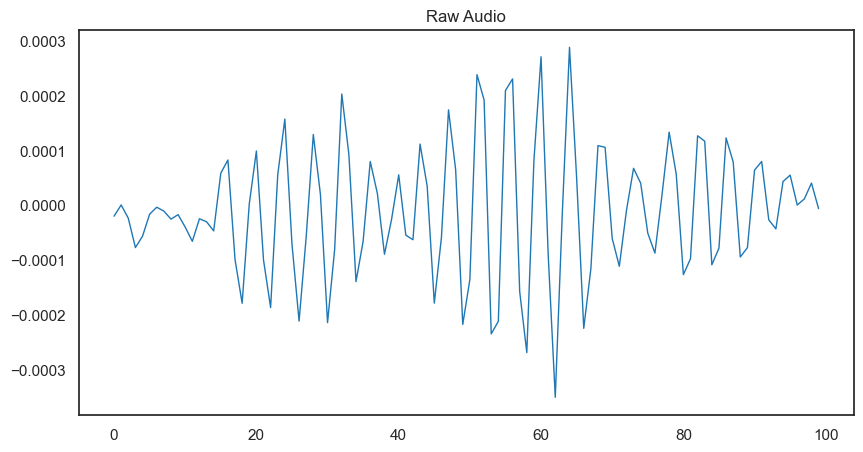

In [23]:
y_trimmed_lower_freq  = librosa.effects.pitch_shift(y_trimmed, sr=sr,
                                                   n_steps=n_steps_down)
y_sample_lower_freq  = pd.Series(y_trimmed_lower_freq[1500:1600])
pd.Series(y_sample_lower_freq).plot(figsize=(10,5), 
                  lw=1, 
                  title='Raw Audio')
idp.Audio(y_trimmed_lower_freq, rate= sr)